In [9]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

True

In [5]:
model = ChatGoogleGenerativeAI(model = "gemini-2.0-flash")

In [6]:
def add(a,b):
    """
    to add two numbers
    """
    return a+b

def mul(a,b):
    """
    to multiply two numbers
    """
    return a*b

tools = [add, mul]

llm_bound = model.bind_tools(tools)

In [7]:
def llm_call(state: MessagesState):
    return {"messages": llm_bound.invoke(state["messages"])}

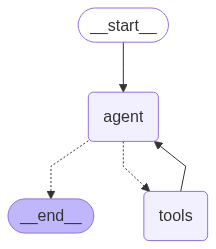

In [12]:
graph = StateGraph(MessagesState)

graph.add_node("agent", llm_call)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools","agent")

wf = graph.compile()
wf

In [13]:
output = wf.invoke({"messages": "add 2 and 3, multiply the result with 5"})

In [14]:
for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

add 2 and 3, multiply the result with 5
================================== Ai Message ==================================
Tool Calls:
  add (105ef629-4ef9-4ce4-9b96-99e7857f5d57)
 Call ID: 105ef629-4ef9-4ce4-9b96-99e7857f5d57
  Args:
    a: 2.0
    b: 3.0
================================= Tool Message =================================
Name: add

5.0
================================== Ai Message ==================================
Tool Calls:
  mul (8b101116-06e0-48c8-adcc-fa2e781205bc)
 Call ID: 8b101116-06e0-48c8-adcc-fa2e781205bc
  Args:
    a: 5.0
    b: 5.0
================================= Tool Message =================================
Name: mul

25.0
================================== Ai Message ==================================

The result is 25.


In [15]:
output

{'messages': [HumanMessage(content='add 2 and 3, multiply the result with 5', additional_kwargs={}, response_metadata={}, id='1e6de066-0af8-437f-b16e-a7a2c139dc20'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"a": 2.0, "b": 3.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--26b41dce-f763-403a-8675-5ef4876f4502-0', tool_calls=[{'name': 'add', 'args': {'a': 2.0, 'b': 3.0}, 'id': '105ef629-4ef9-4ce4-9b96-99e7857f5d57', 'type': 'tool_call'}]),
  ToolMessage(content='5.0', name='add', id='7f01356d-27cc-4d06-a2b5-6d7b29a7acce', tool_call_id='105ef629-4ef9-4ce4-9b96-99e7857f5d57'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'mul', 'arguments': '{"a": 5.0, "b": 5.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemi

In [40]:
# let say i want to make custome reducer

def add_reducer(left: list or None, right: list or None) -> list:

    if not left:
        left = []
    if not right:
        right = []
    print(left," ", right)
    return left + right

In [41]:
from typing import TypedDict, Annotated

class State(MessagesState):

   foo: Annotated[list[int], add_reducer]

In [42]:
def node(state):
    return {"foo": [state["foo"][-1]+1]}

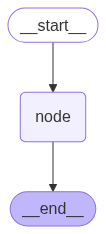

In [43]:
graph = StateGraph(State)

graph.add_node("node", node)

graph.add_edge(START, "node")
graph.add_edge("node", END)

wf = graph.compile()
wf

In [44]:
wf.invoke({"foo": None})

[]   []


IndexError: list index out of range